# P00b — CEPII GeoDist

Load and explore the CEPII GeoDist dataset (bilateral distances + geographic/cultural metadata). Convert to Arrow.

**Source:** [CEPII GeoDist](https://cepii.fr/CEPII/en/bdd_modele/bdd_modele_item.asp?id=6) — Mayer & Zignago 2011. Two files:
- `geo_cepii.dta` — 238 countries, coordinates, area, languages, colonial history
- `dist_cepii.dta` — 50,176 dyadic pairs (224²), distances, contiguity, language, colonial ties

Static dataset (no temporal dimension).

In [1]:
include("phase00b/functions/load_phase00b.jl")
using Graphs, VegaLite, Statistics

## 1. Load, Remap, Derive Edges, Write Arrow

Uses `geodist_process_all()` — loads both .dta files via StatFiles, applies ISO3 remap, derives `ggis_shared_lineage`, writes Arrow.

In [2]:
result = geodist_process_all()
geo = result.geo
dist = result.dist
println("\ngeo: $(nrow(geo)) countries, dist: $(nrow(dist)) pairs")

238 countries × 34 columns


Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,Union
1,iso2,,AD,,ZW,0,"Union{Missing, String}"
2,iso3,,ABW,,ZWE,0,"Union{Missing, String}"
3,cnum,436.298,4,432.0,931,0,"Union{Missing, Int16}"
4,country,,Afghanistan,,Zimbabwe,0,"Union{Missing, String}"
5,pays,,Afghanistan,,Îles Wallis et Futuna,0,"Union{Missing, String}"
6,area,7.58139e5,7,105854.0,17075400,0,"Union{Missing, Int32}"
7,dis_int,203.883,0.995137,122.361,1554.24,0,"Union{Missing, Float32}"
8,landlocked,0.159664,0.0,0.0,1.0,0,"Union{Missing, Float32}"
9,continent,,Africa,,Pacific,0,"Union{Missing, String}"


In [3]:
first(geo, 5)

Row,iso2,iso3,cnum,country,pays,area,dis_int,landlocked,continent,city_en,city_fr,lat,lon,cap,maincity,citynum,langoff_1,langoff_2,langoff_3,lang20_1,lang20_2,lang20_3,lang20_4,lang9_1,lang9_2,lang9_3,lang9_4,colonizer1,colonizer2,colonizer3,colonizer4,short_colonizer1,short_colonizer2,short_colonizer3
,String?,String?,Int16?,String?,String?,Int32?,Float32?,Float32?,String?,String?,String?,Float32?,Float32?,Int8?,Int8?,Float32?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?
1,AD,AND,20,Andorra,Andorre,453,8.0054,0.0,Europe,Andorra la Vella,Andorre-la-Vieille,42.5,1.5,1,1,7.0,Catalan,Spanish,,Catalan,Spanish,,,,,,,,,,,,,
2,AE,ARE,784,United Arab Emirates,Emirats arabes unis,83657,108.789,0.0,Asia,Abu Dhabi,Abou Dhabi,24.4667,54.4167,1,1,9.0,Arabic,,,Arabic,,,,,,,,GBR,,,,,,
3,AF,AFG,4,Afghanistan,Afghanistan,652225,303.761,1.0,Asia,Kabul,Kaboul,34.5167,69.2,1,1,25.0,Persian,,,Persian,Pashtu,,,Hazaragi,Uzbek,,,,,,,GBR,,
4,AG,ATG,28,Antigua and Barbuda,Antigua-et-Barbuda,442,7.9076,0.0,America,Saint John's,Saint John's,17.1333,-61.8333,1,1,15.0,English,,,English,Leeward Caribbean Creole English,,,,,,,GBR,,,,,,
5,AI,AIA,660,Anguilla,Anguilla,102,3.79869,0.0,America,The Valley,The Valley,18.2167,-63.0667,1,1,2.0,English,,,English,Leeward Caribbean Creole English,,,,,,,GBR,,,,,,


## 2. Inspect Edge Data

In [4]:
println("$(nrow(dist)) pairs x $(ncol(dist)) columns")
println("Columns: $(names(dist))")
println()
println("Edge features:")
println("  Contiguous pairs:       $(count(x -> !ismissing(x) && x == 1, dist.contig))")
println("  Common official lang:   $(count(x -> !ismissing(x) && x == 1, dist.comlang_off))")
println("  Common ethnic lang:     $(count(x -> !ismissing(x) && x == 1, dist.comlang_ethno))")
println("  Colonial relationship:  $(count(x -> !ismissing(x) && x == 1, dist.colony))")
println("  Common colonizer:       $(count(x -> !ismissing(x) && x == 1, dist.comcol))")
println("  Same country (ever):    $(count(x -> !ismissing(x) && x == 1, dist.smctry))")
println("  ggis_shared_lineage:    $(count(==(1), dist.ggis_shared_lineage))")
println()
println("Distance (pop-weighted) range: $(round(minimum(skipmissing(dist.distw)), digits=0)) - $(round(maximum(skipmissing(dist.distw)), digits=0)) km")

50176 pairs × 14 columns
Unique countries: 224

Edge features:
  Contiguous pairs:       616
  Common official lang:   8750
  Common ethnic lang:     8488
  Colonial relationship:  482
  Common colonizer:       5886
  Same country (ever):    401

Distance (pop-weighted) range: 1.0 – 19781.0 km


## 3. QoG Alignment

In [5]:
qog = DataFrame(Arrow.Table("data/qog_std_ts_jan25_aug.arrow"))
qog_codes = Set(unique(skipmissing(qog.ident_ccodealp)))
dist_codes = Set(unique(skipmissing(dist.iso_o)))
geo_codes = Set(unique(skipmissing(geo.iso3)))

matched = length(intersect(dist_codes, qog_codes))
in_dist_not_qog = sort(collect(setdiff(dist_codes, qog_codes)))
in_qog_not_dist = sort(collect(setdiff(qog_codes, dist_codes)))

println("QoG: $(length(qog_codes))  GeoDist: $(length(dist_codes))  Matched: $matched")
println()
println("In GeoDist but NOT in QoG ($(length(in_dist_not_qog))):")
for c in in_dist_not_qog; println("  $c"); end
println()
println("In QoG but NOT in GeoDist ($(length(in_qog_not_dist))):")
for c in in_qog_not_dist; println("  $c"); end

QoG: 202  GeoDist: 224  Matched: 187

In GeoDist but NOT in QoG (37):
  ABW
  AIA
  ANT
  BMU
  CCK
  COK
  CXR
  CYM
  ESH
  FLK
  FRO
  GIB
  GLP
  GRL
  GUF
  HKG
  MAC
  MNP
  MSR
  MTQ
  NCL
  NFK
  NIU
  PAL
  PCN
  PRI
  PYF
  REU
  ROM
  SHN
  SPM
  TCA
  TKL
  TMP
  VGB
  WLF
  ZAR

In QoG but NOT in GeoDist (15):
  COD
  CSK
  DDR
  LIE
  MCO
  MNE
  ROU
  SCG
  SRB
  SSD
  SUN
  TLS
  VDR
  XTI
  YMD


## 4. Colonial Network

Colonial ties as transmission channels — these edges persist long after independence, predicting trade, legal systems, language, institutional structure, and migration patterns.

In [7]:
# Colonial relationships — who colonized whom?
colonial = filter(r -> !ismissing(r.colony) && r.colony == 1, dist)
println("$(nrow(colonial)) colonial pairs (directed)")
println()

# Which countries appear most often as colonial partners?
all_colonial_countries = vcat(colonial.iso_o, colonial.iso_d)
colonial_counts = combine(groupby(DataFrame(iso3=all_colonial_countries), :iso3), nrow => :n_colonial_ties)
sort!(colonial_counts, :n_colonial_ties, rev=true)
println("Top 15 countries by colonial tie count:")
first(colonial_counts, 15)

482 colonial pairs (directed)

Top 15 countries by colonial tie count:


Row,iso3,n_colonial_ties
,String,Int64
1,GBR,162
2,FRA,78
3,ESP,50
4,RUS,30
5,TUR,30
6,DEU,20
7,PRT,16
8,USA,16
9,JPN,12


In [8]:
# Common colonizer network — countries colonized by the same power
# These share institutional DNA without direct bilateral colonial ties
comcol = filter(r -> !ismissing(r.comcol) && r.comcol == 1, dist)
println("$(nrow(comcol)) common-colonizer pairs")
println()

# Countries with the most common-colonizer siblings
comcol_countries = vcat(comcol.iso_o, comcol.iso_d)
comcol_counts = combine(groupby(DataFrame(iso3=comcol_countries), :iso3), nrow => :n_siblings)
sort!(comcol_counts, :n_siblings, rev=true)
println("Top 15 countries by common-colonizer sibling count:")
first(comcol_counts, 15)

5886 common-colonizer pairs

Top 15 countries by common-colonizer sibling count:


Row,iso3,n_siblings
,String,Int64
1,VUT,198
2,CXR,138
3,NRU,138
4,AIA,134
5,ARE,134
6,ATG,134
7,BGD,134
8,BHR,134
9,BHS,134


## 5. Contiguity Network Visualization

Geographic nearest neighbors — countries sharing a border.

In [9]:
using Graphs

# Build contiguity graph from QoG-matched countries only
qog_matched = intersect(dist_codes, qog_codes)
matched_list = sort(collect(qog_matched))
idx = Dict(c => i for (i, c) in enumerate(matched_list))

g = SimpleGraph(length(matched_list))
contig_edges = filter(r -> !ismissing(r.contig) && r.contig == 1 && 
                           String(r.iso_o) in qog_matched && String(r.iso_d) in qog_matched &&
                           String(r.iso_o) < String(r.iso_d),  # avoid double-counting
                      dist)

for r in eachrow(contig_edges)
    add_edge!(g, idx[String(r.iso_o)], idx[String(r.iso_d)])
end

println("Contiguity graph (QoG-matched only):")
println("  Nodes: $(nv(g))")
println("  Edges: $(ne(g))")
println("  Connected components: $(length(connected_components(g)))")
println()

# Degree distribution — how many land borders per country
degs = degree(g)
deg_df = DataFrame(iso3=matched_list, degree=degs)
sort!(deg_df, :degree, rev=true)
println("Top 15 most connected (by land borders):")
first(deg_df, 15)

Contiguity graph (QoG-matched only):
  Nodes: 187
  Edges: 282
  Connected components: 43

Top 15 most connected (by land borders):


Row,iso3,degree
,String,Int64
1,CHN,14
2,RUS,14
3,BRA,9
4,DEU,9
5,SDN,8
6,TUR,8
7,AUT,7
8,FRA,7
9,IRN,7


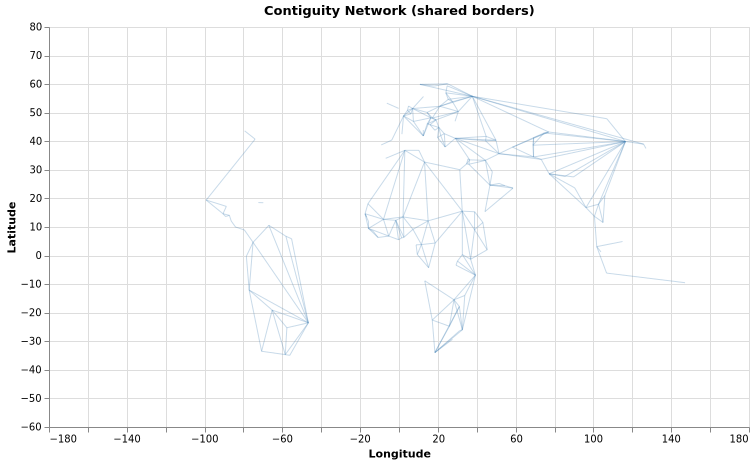

In [10]:
# Visualize contiguity network on a world map using VegaLite
using VegaLite

# Build edge list with coordinates for contiguous pairs
geo_coords = select(geo, :iso3, :lat, :lon)

edge_data = DataFrame()
for r in eachrow(contig_edges)
    o = String(r.iso_o)
    d = String(r.iso_d)
    o_row = filter(row -> !ismissing(row.iso3) && String(row.iso3) == o, geo_coords)
    d_row = filter(row -> !ismissing(row.iso3) && String(row.iso3) == d, geo_coords)
    if nrow(o_row) > 0 && nrow(d_row) > 0
        push!(edge_data, (
            lat_o=Float64(o_row[1, :lat]), lon_o=Float64(o_row[1, :lon]),
            lat_d=Float64(d_row[1, :lat]), lon_d=Float64(d_row[1, :lon]),
            iso_o=o, iso_d=d
        ), promote=true)
    end
end

edge_data |> @vlplot(
    width=700, height=400,
    title="Contiguity Network (shared borders)",
    mark={:rule, opacity=0.3, color="steelblue"},
    x={:lon_o, type=:quantitative, scale={domain=[-180, 180]}, title="Longitude"},
    y={:lat_o, type=:quantitative, scale={domain=[-60, 80]}, title="Latitude"},
    x2=:lon_d,
    y2=:lat_d
)

In [12]:
# Verify: Australia's ggis_shared_lineage partners
aus_lineage = filter(r -> (String(r.iso_o) == "AUS" || String(r.iso_d) == "AUS") && r.ggis_shared_lineage == 1, dist)
aus_lineage[!, :partner] = [String(r.iso_o) == "AUS" ? String(r.iso_d) : String(r.iso_o) for r in eachrow(aus_lineage)]
println("Australia's ggis_shared_lineage partners: $(length(unique(aus_lineage.partner)))")
println(sort(unique(aus_lineage.partner)))

Australia's ggis_shared_lineage partners: 81
["AIA", "ARE", "ATG", "AUS", "BGD", "BHR", "BHS", "BLZ", "BMU", "BRB", "BRN", "BWA", "CAN", "CCK", "COK", "CXR", "CYM", "CYP", "DMA", "EGY", "ERI", "FJI", "FLK", "GHA", "GIB", "GMB", "GRD", "GUY", "HKG", "IND", "IRL", "ISR", "JAM", "JOR", "KEN", "KIR", "KNA", "KWT", "LCA", "LKA", "LSO", "MDV", "MLT", "MMR", "MSR", "MUS", "MWI", "MYS", "NGA", "NIU", "NRU", "NZL", "PAK", "PAL", "PCN", "PLW", "PNG", "QAT", "SDN", "SGP", "SHN", "SLB", "SLE", "SOM", "SWZ", "SYC", "TCA", "TKL", "TON", "TTO", "TUV", "TZA", "UGA", "USA", "VCT", "VGB", "VUT", "YEM", "ZAF", "ZMB", "ZWE"]


## 5. Australia — Multi-Layer Connectivity

Australia has zero land borders but is coupled through proximity, language, colonial ties, and institutional lineage. This demonstrates why multiple edge types matter — a purely geographic ρ would miss Australia's actual connectivity entirely.

In [13]:
# Australia's connections ranked by TIE STRENGTH including ggis_shared_lineage
aus2 = filter(r -> String(r.iso_o) == "AUS" || String(r.iso_d) == "AUS", dist)
aus2[!, :partner] = [String(r.iso_o) == "AUS" ? String(r.iso_d) : String(r.iso_o) for r in eachrow(aus2)]
aus2_unique = combine(groupby(aus2, :partner), first)

# Recount ties including ggis_shared_lineage
aus2_unique[!, :n_ties] = zeros(Int, nrow(aus2_unique))
for col in [:contig, :comlang_off, :comlang_ethno, :colony, :comcol, :smctry, :ggis_shared_lineage]
    aus2_unique[!, :n_ties] .+= [coalesce(v, 0) == 1 ? 1 : 0 for v in aus2_unique[!, col]]
end

sort!(aus2_unique, [:n_ties, :distw], rev=[true, false])
println("Australia's top connections (with ggis_shared_lineage):")
println("─"^100)
first(select(aus2_unique, :partner, :distw, :contig, :comlang_off, :comlang_ethno, :colony, :comcol, :smctry, :ggis_shared_lineage, :n_ties), 25)

Australia's top connections (with ggis_shared_lineage):
────────────────────────────────────────────────────────────────────────────────────────────────────


Row,partner,distw,contig,comlang_off,comlang_ethno,colony,comcol,smctry,ggis_shared_lineage,n_ties
,String,Float64?,Int8?,Int8?,Int8?,Int8?,Int8?,Int8?,Int8,Int64
1,CXR,missing,0,1,1,1,0,1,1,5
2,PNG,3087.28,0,1,1,1,0,0,1,4
3,NRU,4395.37,0,1,1,1,0,0,1,4
4,CCK,missing,0,0,1,1,0,1,1,4
5,NZL,2736.36,0,1,1,0,0,0,1,3
6,VUT,2989.3,0,1,1,0,0,0,1,3
7,FJI,3755.17,0,1,1,0,0,0,1,3
8,NIU,4733.6,0,1,1,0,0,0,1,3
9,PLW,4829.43,0,1,1,0,0,0,1,3


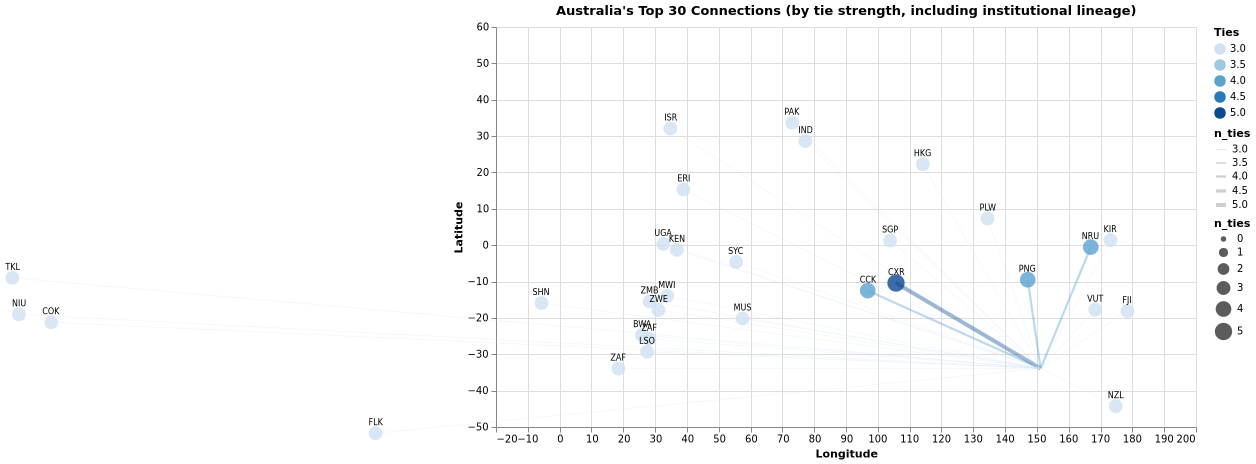

In [14]:
# Visualize Australia's neighborhood with ggis_shared_lineage
# Show top 30 by tie strength (not distance)
aus_viz = first(sort(aus2_unique, [:n_ties, :distw], rev=[true, false]), 30)

# Get coordinates for partners
aus_viz = innerjoin(aus_viz, rename(geo_coords, :iso3 => :partner), on=:partner)

# Australia's coordinates
aus_lat = Float64(first(filter(r -> !ismissing(r.iso3) && String(r.iso3) == "AUS", geo_coords)).lat)
aus_lon = Float64(first(filter(r -> !ismissing(r.iso3) && String(r.iso3) == "AUS", geo_coords)).lon)

aus_viz[!, :aus_lat] .= aus_lat
aus_viz[!, :aus_lon] .= aus_lon
aus_viz[!, :lat] = Float64.(aus_viz.lat)
aus_viz[!, :lon] = Float64.(aus_viz.lon)
aus_viz[!, :distw_f] = [ismissing(v) ? 0.0 : Float64(v) for v in aus_viz.distw]
aus_viz[!, :n_ties] = Int.(aus_viz.n_ties)

aus_viz |> @vlplot(
    width=700, height=400,
    title="Australia's Top 30 Connections (by tie strength, including institutional lineage)",
    layer=[
        {
            mark={:rule, opacity=0.4},
            encoding={
                x={field=:aus_lon, type=:quantitative, scale={domain=[-20, 200]}, title="Longitude"},
                y={field=:aus_lat, type=:quantitative, scale={domain=[-50, 60]}, title="Latitude"},
                x2={field=:lon},
                y2={field=:lat},
                color={field=:n_ties, type=:quantitative, scale={scheme="blues"}, title="Ties"},
                strokeWidth={field=:n_ties, type=:quantitative, scale={range=[0.5, 4]}}
            }
        },
        {
            mark={:circle, opacity=0.8},
            encoding={
                x={field=:lon, type=:quantitative},
                y={field=:lat, type=:quantitative},
                size={field=:n_ties, type=:quantitative, scale={range=[30, 300]}},
                color={field=:n_ties, type=:quantitative, scale={scheme="blues"}},
                tooltip=[{field=:partner}, {field=:distw_f, title="Distance (km)"}, {field=:n_ties, title="Ties"}]
            }
        },
        {
            mark={:text, fontSize=8, dy=-10},
            encoding={
                x={field=:lon, type=:quantitative},
                y={field=:lat, type=:quantitative},
                text={field=:partner}
            }
        }
    ]
)